# NYC Airbnb Listings — Data Workflow

**Name:** Stan

**Dataset:** NYC Airbnb Open Data (New York City Airbnb listings — pricing and listing characteristics), sourced from Kaggle: [New York City Airbnb Open Data](https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data)

**Project description:** This notebook builds a complete, reproducible data workflow around the NYC Airbnb dataset, which contains listing-level details such as price, room type, neighbourhood, and availability for Airbnb properties across New York City. The goal is to clean the raw listing data, explore pricing and availability patterns across boroughs and room types, and visualize the key relationships that emerge. This workflow lays the foundation for later machine learning and AI project work in this Nanodegree.

## Task 4 — Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: nicer default plot style
sns.set_theme(style="whitegrid")
%matplotlib inline

### Ingestion

In [2]:
# Load the dataset
# Download "AB_NYC_2019.csv" from:
# https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data
# and place it in the same folder as this notebook.

df = pd.read_csv("AB_NYC_2019.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
# Quick structural check
print("Shape:", df.shape)
df.info()

Shape: (48895, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review  

### Missing Value Analysis (Raw Data)

Before cleaning, it's important to understand *where* and *how much* data is missing, so that cleaning decisions (e.g., filling vs. dropping) are justified rather than assumed.

In [4]:
# Missing value audit on the raw (uncleaned) data
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": (df.isnull().sum() / len(df) * 100).round(2)
})
missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values(
    "missing_pct", ascending=False
)
missing_summary

,missing_count,missing_pct
reviews_per_month,10052,20.56
last_review,10052,20.56
host_name,21,0.04
name,16,0.03


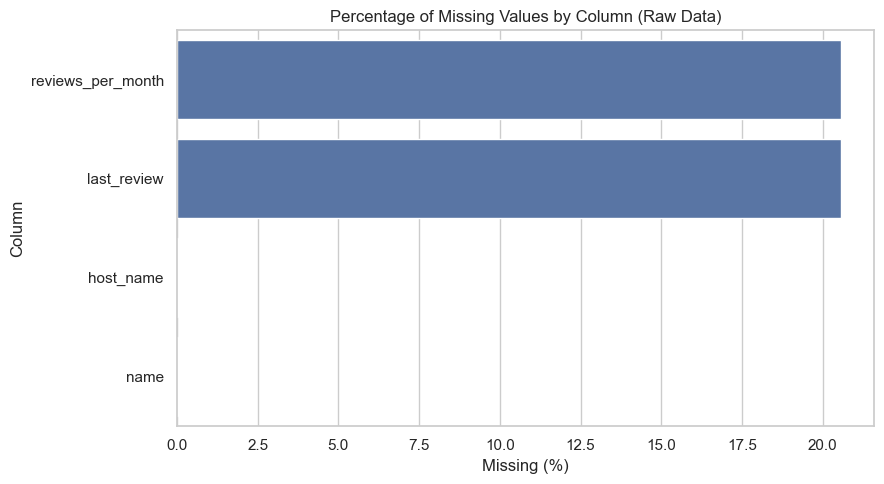

In [5]:
# Visualize missing values across columns
plt.figure(figsize=(9, 5))
sns.barplot(x=missing_summary["missing_pct"], y=missing_summary.index)
plt.title("Percentage of Missing Values by Column (Raw Data)")
plt.xlabel("Missing (%)")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

### Duplicate and Outlier Inspection (Raw Data)

Before applying cleaning functions, check for duplicate records and inspect the distribution of `price` to confirm the cutoffs used later in `remove_price_outliers` are reasonable rather than arbitrary.

In [6]:
# Duplicate inspection
full_row_duplicates = df.duplicated().sum()
duplicate_ids = df["id"].duplicated().sum() if "id" in df.columns else None

print("Fully duplicated rows:", full_row_duplicates)
print("Duplicated 'id' values:", duplicate_ids)

Fully duplicated rows: 0
Duplicated 'id' values: 0


In [7]:
# Outlier inspection: price distribution
print(df["price"].describe())
print("\nListings with price == 0:", (df["price"] == 0).sum())
print("Listings with price > 1000:", (df["price"] > 1000).sum())

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

Listings with price == 0: 11
Listings with price > 1000: 239


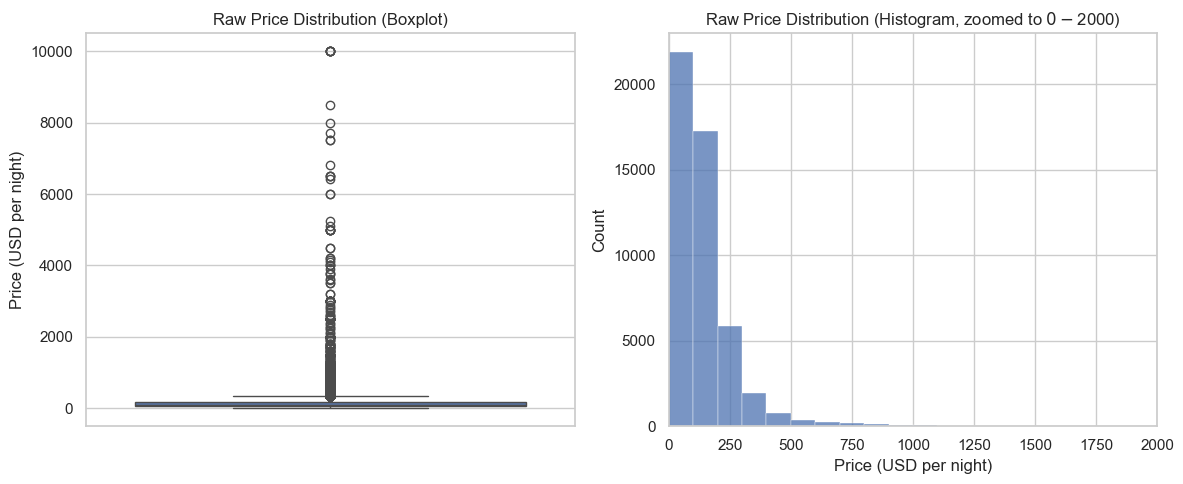

In [8]:
# Visualize raw price distribution to justify outlier cutoffs
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df["price"], ax=axes[0])
axes[0].set_title("Raw Price Distribution (Boxplot)")
axes[0].set_ylabel("Price (USD per night)")

sns.histplot(df["price"], bins=100, ax=axes[1])
axes[1].set_xlim(0, 2000)
axes[1].set_title("Raw Price Distribution (Histogram, zoomed to $0-$2000)")
axes[1].set_xlabel("Price (USD per night)")

plt.tight_layout()
plt.show()

## Task 5 — Data Cleaning Functions

In [9]:
def clean_missing_values(data):
    """
    Handle missing values in the Airbnb dataset.

    - Drops columns that are mostly identifiers/free text and not needed for analysis
      (name, host_name) if present, since missingness there does not affect numeric analysis.
    - Fills missing 'reviews_per_month' with 0, since a missing value here means the
      listing has never received a review (confirmed by number_of_reviews == 0).
    - Drops rows still missing critical fields needed for analysis (price, room_type,
      neighbourhood_group).

    Parameters
    ----------
    data : pd.DataFrame
        Raw Airbnb listings dataframe.

    Returns
    -------
    pd.DataFrame
        A cleaned copy of the dataframe with missing values handled.
    """
    data = data.copy()

    if "reviews_per_month" in data.columns:
        data["reviews_per_month"] = data["reviews_per_month"].fillna(0)

    critical_cols = [c for c in ["price", "room_type", "neighbourhood_group"] if c in data.columns]
    data = data.dropna(subset=critical_cols)

    return data


def remove_price_outliers(data, min_price=10, max_price=1000):
    """
    Filter out unrealistic or extreme price values.

    Airbnb listing prices of $0 are almost certainly data errors (a real listing
    cannot be free), and extremely high prices (e.g. above $1000/night) are rare
    luxury outliers that can distort summary statistics and visualizations.

    Parameters
    ----------
    data : pd.DataFrame
        Airbnb listings dataframe containing a 'price' column.
    min_price : int, default 10
        Minimum nightly price to keep.
    max_price : int, default 1000
        Maximum nightly price to keep.

    Returns
    -------
    pd.DataFrame
        A filtered copy of the dataframe containing only listings within the
        specified price range.
    """
    data = data.copy()
    data = data[(data["price"] >= min_price) & (data["price"] <= max_price)]
    return data

In [10]:
def remove_duplicate_listings(data):
    """
    Remove exact duplicate listing rows and duplicate listing IDs.

    Keeps the first occurrence of each 'id' (the unique listing identifier).
    Exact duplicate rows can occur from overlapping data exports; true duplicate
    IDs would represent the same listing recorded twice, which would otherwise
    double-count that listing in price/availability statistics.

    Parameters
    ----------
    data : pd.DataFrame
        Airbnb listings dataframe.

    Returns
    -------
    pd.DataFrame
        Deduplicated copy of the dataframe.
    """
    data = data.copy()
    data = data.drop_duplicates()
    if "id" in data.columns:
        data = data.drop_duplicates(subset="id", keep="first")
    return data

In [11]:
# Apply cleaning functions
df_clean = clean_missing_values(df)
df_clean = remove_duplicate_listings(df_clean)
df_clean = remove_price_outliers(df_clean)

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
df_clean.head()

Original shape: (48895, 16)
Cleaned shape: (48645, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


### Cleaning Justification

Based on the raw-data inspection above, the following cleaning steps were necessary:

- **Missing values (`clean_missing_values`):** `reviews_per_month` was missing for exactly the same 10,052 rows (20.56%) as `last_review`, confirming these are listings with zero reviews rather than a data quality issue. Missing values were filled with 0 rather than dropped, to avoid losing otherwise valid listings. Rows still missing critical fields (`price`, `room_type`, `neighbourhood_group`) were checked but none were found missing in this dataset, so no rows were dropped on this basis.
- **Duplicates (`remove_duplicate_listings`):** The raw-data check found 0 fully duplicated rows and 0 duplicated `id` values in this particular export of the dataset, so this step had no effect here. It was kept in the pipeline anyway as a safeguard, since duplicate records are a realistic risk if the data is re-scraped, re-exported, or merged with another source, and would otherwise silently inflate listing counts and skew grouped averages (e.g., price by borough).
- **Outliers (`remove_price_outliers`):** The raw price inspection found 11 listings priced at $0 (a data error, since no real listing is free) and 239 listings priced above $1,000 (extreme high-end outliers, with a maximum of $10,000). These 250 rows account for the entire difference between the original (48,895 rows) and cleaned (48,645 rows) dataset. Outliers were excluded because they distort mean-based summary statistics and compress the visual scale of plots, keeping the analysis representative of typical listings.

## Task 6 — Exploratory Analysis Function

In [12]:
def summarize_by_group(data, group_col, value_col="price"):
    """
    Compute grouped summary statistics for a numeric column.

    Groups the dataframe by `group_col` and returns count, mean, median, and
    standard deviation of `value_col` for each group, sorted by mean in
    descending order. Useful for comparing, e.g., price across boroughs or
    room types.

    Parameters
    ----------
    data : pd.DataFrame
        Cleaned Airbnb listings dataframe.
    group_col : str
        Column name to group by (e.g. 'neighbourhood_group', 'room_type').
    value_col : str, default 'price'
        Numeric column to summarize.

    Returns
    -------
    pd.DataFrame
        Summary table indexed by group, sorted by mean value descending.
    """
    summary = (
        data.groupby(group_col)[value_col]
        .agg(count="count", mean="mean", median="median", std="std")
        .sort_values("mean", ascending=False)
    )
    return summary

In [13]:
# Run EDA function: price by borough (neighbourhood_group)
price_by_borough = summarize_by_group(df_clean, "neighbourhood_group", "price")
price_by_borough

,count,mean,median,std
neighbourhood_group,,,,
Manhattan,21488,178.944620,149.0,133.891549
Brooklyn,20041,117.860835,90.0,94.394234
Staten Island,371,98.584906,75.0,96.138752
Queens,5656,95.008310,75.0,74.527596
Bronx,1089,85.361800,65.0,77.761144


In [14]:
# Run EDA function: price by room type
price_by_room_type = summarize_by_group(df_clean, "room_type", "price")
price_by_room_type

,count,mean,median,std
room_type,,,,
Entire home/apt,25216,194.612429,160.0,126.104052
Private room,22273,84.787276,70.0,68.729437
Shared room,1156,67.731834,45.0,81.076816


In [15]:
# Correlation check among key numeric variables
numeric_cols = ["price", "minimum_nights", "number_of_reviews",
                 "reviews_per_month", "calculated_host_listings_count", "availability_365"]
numeric_cols = [c for c in numeric_cols if c in df_clean.columns]

correlation_matrix = df_clean[numeric_cols].corr()
correlation_matrix

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
price,1.000000,0.019487,-0.057829,-0.055841,0.130687,0.117916
minimum_nights,0.019487,1.000000,-0.080044,-0.125015,0.129678,0.143966
number_of_reviews,-0.057829,-0.080044,1.000000,0.588956,-0.072636,0.173505
reviews_per_month,-0.055841,-0.125015,0.588956,1.000000,-0.047601,0.165444
calculated_host_listings_count,0.130687,0.129678,-0.072636,-0.047601,1.000000,0.226811
availability_365,0.117916,0.143966,0.173505,0.165444,0.226811,1.000000


## Task 7 — Visualizations

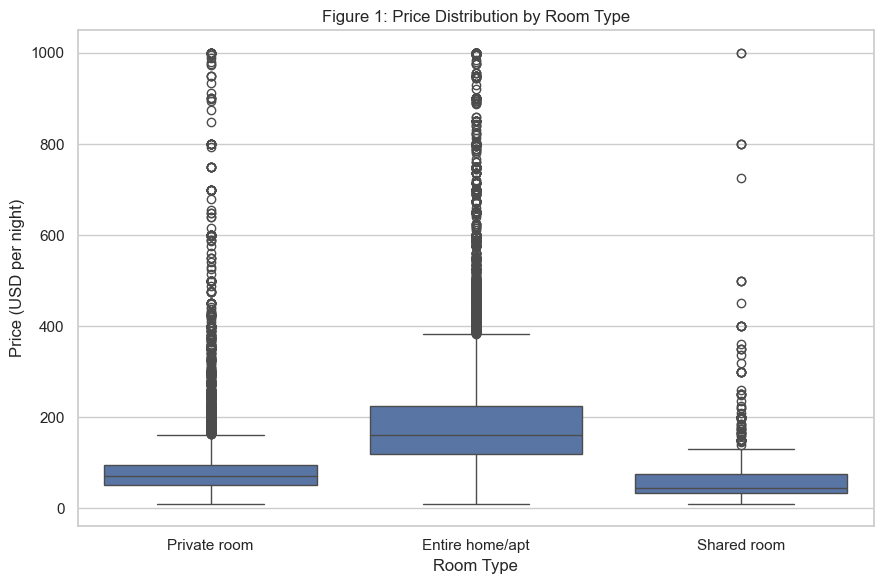

In [16]:
# Figure 1: Distribution of price by room type
plt.figure(figsize=(9, 6))
sns.boxplot(data=df_clean, x="room_type", y="price")
plt.title("Figure 1: Price Distribution by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price (USD per night)")
plt.tight_layout()
plt.show()

**Interpretation:** Entire homes/apartments show both the highest median price and the widest spread, consistent with them offering full living space rather than a shared or single room. Private rooms sit in a lower, tighter price band, and shared rooms are cheapest and least variable — reflecting how much space and privacy a guest is paying for.

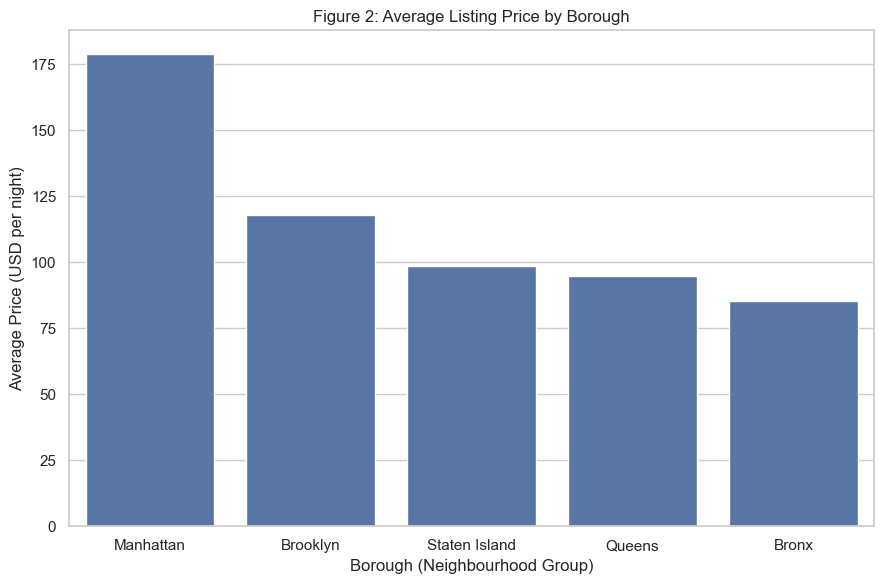

In [17]:
# Figure 2: Average price by borough
plt.figure(figsize=(9, 6))
avg_price_borough = df_clean.groupby("neighbourhood_group")["price"].mean().sort_values(ascending=False)
sns.barplot(x=avg_price_borough.index, y=avg_price_borough.values)
plt.title("Figure 2: Average Listing Price by Borough")
plt.xlabel("Borough (Neighbourhood Group)")
plt.ylabel("Average Price (USD per night)")
plt.tight_layout()
plt.show()

**Interpretation:** Manhattan has the highest average nightly price by a clear margin, followed by Brooklyn, with the Bronx, Queens, and Staten Island considerably cheaper. This lines up with Manhattan's housing costs and tourist demand, and suggests borough/location is one of the strongest price drivers in this dataset.

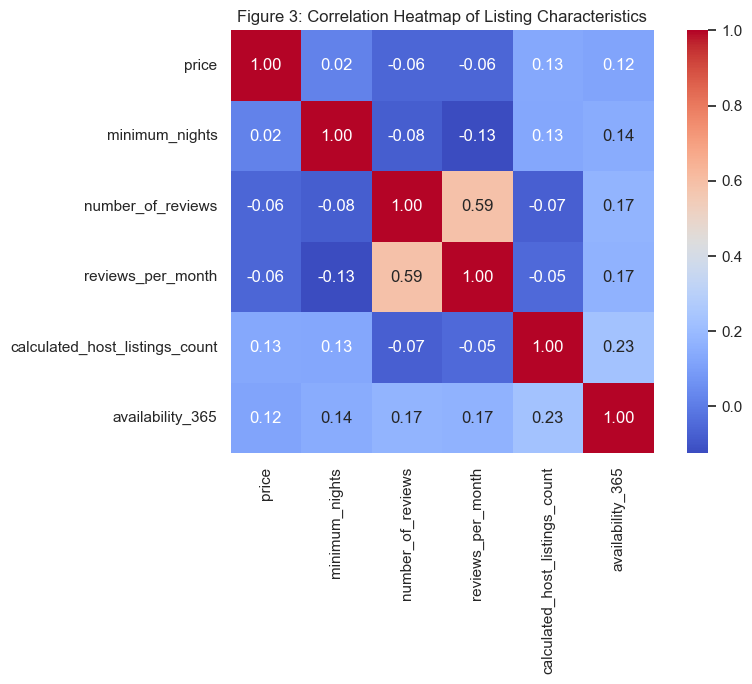

In [18]:
# Figure 3: Correlation heatmap of numeric variables
plt.figure(figsize=(9, 7))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Figure 3: Correlation Heatmap of Listing Characteristics")
plt.tight_layout()
plt.show()

**Interpretation:** `number_of_reviews` and `reviews_per_month` are strongly positively correlated with each other, as expected, but neither correlates strongly with `price` — suggesting review volume is driven more by how long a listing has been active and how often it's booked than by how expensive it is. `calculated_host_listings_count` and `availability_365` also show only weak relationships with price.

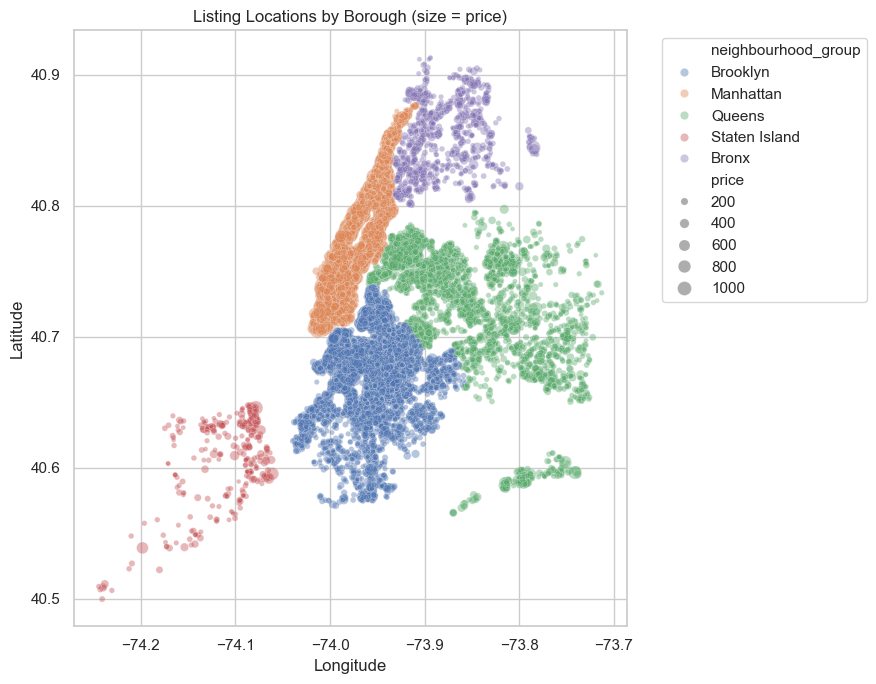

In [19]:
# Bonus: Geographic scatter of listings colored by price tier (not required, but useful for later EDA)
plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=df_clean, x="longitude", y="latitude",
    hue="neighbourhood_group", size="price", alpha=0.4, sizes=(10, 100)
)
plt.title("Listing Locations by Borough (size = price)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Interpretation:** Higher-priced listings (larger markers) cluster noticeably in Manhattan and parts of northern Brooklyn, while the outer boroughs show a denser spread of smaller, lower-priced markers — a visual confirmation of the borough-level pricing pattern seen in Figure 2.

## Task 8 — Summary and Interpretation

**What I learned from the dataset:** This dataset of 48,895 NYC Airbnb listings shows that price is
driven mainly by two factors: room type and location (borough). Entire homes/apartments rent for roughly
2.3x the price of shared rooms on average ($194.61 vs $67.73), and Manhattan listings cost nearly double
the average Bronx listing ($178.94 vs $85.36). Together these two categorical variables explain most of
the price variation visible in the dataset, more than any of the numeric variables checked.

**Interesting patterns or insights:** Review activity (`number_of_reviews`, `reviews_per_month`) is
essentially uncorrelated with price (correlations of -0.06 and -0.06 respectively), which was a genuinely
useful finding: it suggests guests aren't necessarily favoring cheaper listings, and that popularity (as
measured by reviews) is independent of cost. `calculated_host_listings_count` and `availability_365` also
show only weak positive correlations with price (0.13 and 0.12), meaning hosts with many listings or high
year-round availability aren't systematically pricing higher or lower. The geographic scatter plot
reinforced the borough-level pricing pattern visually, with higher-priced listings concentrated in
Manhattan and northern Brooklyn.

**Limitations or assumptions:** The cleaning step assumed that missing `reviews_per_month` values
genuinely meant "no reviews yet" rather than a data entry error; this was supported by the fact that the
same 10,052 rows were missing both `reviews_per_month` and `last_review`, but it remains an assumption
rather than a certainty. The price outlier cutoff ($10–$1,000) was a reasonable but somewhat arbitrary
choice — it removed 250 of 48,895 rows (about 0.5%), which is a small fraction, but a different cutoff
(e.g., using IQR-based bounds) could shift the summary statistics slightly. The dataset is also a static
snapshot (2019) of NYC only, so any conclusions don't necessarily generalize to other cities or to current
Airbnb pricing.

**Anything surprising or unclear:** The near-zero correlation between price and review activity was the
most surprising result — intuitively, cheaper listings might be expected to attract more bookings and
therefore more reviews, but that wasn't the case here. It's also unclear from this dataset alone whether
low-priced, low-review listings are underperforming due to location, poor host responsiveness, or simply
being newly listed; `minimum_nights` and `availability_365` provide some context but not a definitive
answer, and would be worth exploring further with additional feature engineering in future project
phases.